In [1]:
import zipfile
import os

# Pehle dekho file kahan hai
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/yashaskarsrivastava/dataset-2/Actor_02/03-01-08-01-01-01-02.wav
/kaggle/input/datasets/yashaskarsrivastava/dataset-2/Actor_02/03-01-01-01-01-01-02.wav
/kaggle/input/datasets/yashaskarsrivastava/dataset-2/Actor_02/03-01-07-02-01-02-02.wav
/kaggle/input/datasets/yashaskarsrivastava/dataset-2/Actor_02/03-01-07-01-01-02-02.wav
/kaggle/input/datasets/yashaskarsrivastava/dataset-2/Actor_02/03-01-01-01-02-01-02.wav
/kaggle/input/datasets/yashaskarsrivastava/dataset-2/Actor_02/03-01-06-02-02-01-02.wav
/kaggle/input/datasets/yashaskarsrivastava/dataset-2/Actor_02/03-01-04-01-02-01-02.wav
/kaggle/input/datasets/yashaskarsrivastava/dataset-2/Actor_02/03-01-01-01-01-02-02.wav
/kaggle/input/datasets/yashaskarsrivastava/dataset-2/Actor_02/03-01-02-01-01-02-02.wav
/kaggle/input/datasets/yashaskarsrivastava/dataset-2/Actor_02/03-01-03-01-01-01-02.wav
/kaggle/input/datasets/yashaskarsrivastava/dataset-2/Actor_02/03-01-07-01-02-02-02.wav
/kaggle/input/datasets/yashaskarsrivastava/

## libraries ##

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("✅ Saari Libraries Load Ho Gayi!")

✅ Saari Libraries Load Ho Gayi!


## Audio Files Load Karo aur Labels Extract Karo ##

In [3]:
# Dataset path
DATA_PATH = '/kaggle/input/datasets/yashaskarsrivastava/dataset-2/'

# Emotion mapping — filename ke 3rd number se emotion pata chalta hai
emotion_map = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

# Saari files aur emotions collect karo
file_paths = []
emotions = []

for actor in os.listdir(DATA_PATH):
    actor_path = os.path.join(DATA_PATH, actor)
    if os.path.isdir(actor_path):
        for file in os.listdir(actor_path):
            if file.endswith('.wav'):
                # Filename se emotion nikalo
                parts = file.split('-')
                emotion = emotion_map[parts[2]]
                file_paths.append(os.path.join(actor_path, file))
                emotions.append(emotion)

print(f"✅ Total Files : {len(file_paths)}")
print(f"✅ Total Labels: {len(emotions)}")
print("\nEmotion Distribution:")
print(pd.Series(emotions).value_counts())

✅ Total Files : 1440
✅ Total Labels: 1440

Emotion Distribution:
surprised    192
disgust      192
fearful      192
sad          192
happy        192
calm         192
angry        192
neutral       96
Name: count, dtype: int64


## : MFCC Features Extract Karo ##

In [4]:
# MFCC features extract karne ka function
def extract_features(file_path):
    try:
        # Audio file load karo
        audio, sr = librosa.load(file_path, duration=3, offset=0.5)
        
        # MFCC features nikalo (40 features)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
        mfcc_scaled = np.mean(mfcc.T, axis=0)
        
        return mfcc_scaled
    except Exception as e:
        print(f"Error: {file_path} — {e}")
        return None

# Saari files se features nikalo
print("⏳ Features extract ho rahi hain — thoda wait karo...")

X = []
y = []

for i, (file, emotion) in enumerate(zip(file_paths, emotions)):
    features = extract_features(file)
    if features is not None:
        X.append(features)
        y.append(emotion)
    
    # Progress dikhao
    if (i+1) % 200 == 0:
        print(f"  {i+1}/{len(file_paths)} files done...")

X = np.array(X)
y = np.array(y)

print(f"\n✅ Features Shape : {X.shape}")
print(f"✅ Labels Shape   : {y.shape}")
print("\n🎉 Feature Extraction Complete!")

⏳ Features extract ho rahi hain — thoda wait karo...
  200/1440 files done...
  400/1440 files done...
  600/1440 files done...
  800/1440 files done...
  1000/1440 files done...
  1200/1440 files done...
  1400/1440 files done...

✅ Features Shape : (1440, 40)
✅ Labels Shape   : (1440,)

🎉 Feature Extraction Complete!


## Data Prepare Karo — Split aur Scale ##

In [5]:
# Label Encoding — emotions ko numbers mein badlo
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Emotions aur unke numbers:")
for i, emotion in enumerate(le.classes_):
    print(f"  {i} = {emotion}")

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42)

# Scale karo
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"\n✅ Training size : {X_train.shape}")
print(f"✅ Testing size  : {X_test.shape}")
print("\n🎉 Data Ready Hai!")

Emotions aur unke numbers:
  0 = angry
  1 = calm
  2 = disgust
  3 = fearful
  4 = happy
  5 = neutral
  6 = sad
  7 = surprised

✅ Training size : (1152, 40)
✅ Testing size  : (288, 40)

🎉 Data Ready Hai!


## Model Train Karo ##

In [6]:
# MLP Classifier (Neural Network)
print("⏳ Model train ho raha hai — wait karo...")

model = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    verbose=False
)

model.fit(X_train, y_train)

print("✅ Model Train Ho Gaya!")

# Prediction karo
y_pred = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"\n🎯 Accuracy : {acc:.4f} ({acc*100:.2f}%)")

⏳ Model train ho raha hai — wait karo...
✅ Model Train Ho Gaya!

🎯 Accuracy : 0.7153 (71.53%)


##  Evaluation aur Graphs ## 

      📊 CLASSIFICATION REPORT
              precision    recall  f1-score   support

       angry       0.72      0.68      0.70        34
        calm       0.83      0.85      0.84        40
     disgust       0.78      0.69      0.73        45
     fearful       0.62      0.90      0.74        31
       happy       0.74      0.49      0.59        41
     neutral       0.61      0.58      0.59        19
         sad       0.69      0.71      0.70        35
   surprised       0.69      0.79      0.74        43

    accuracy                           0.72       288
   macro avg       0.71      0.71      0.70       288
weighted avg       0.72      0.72      0.71       288



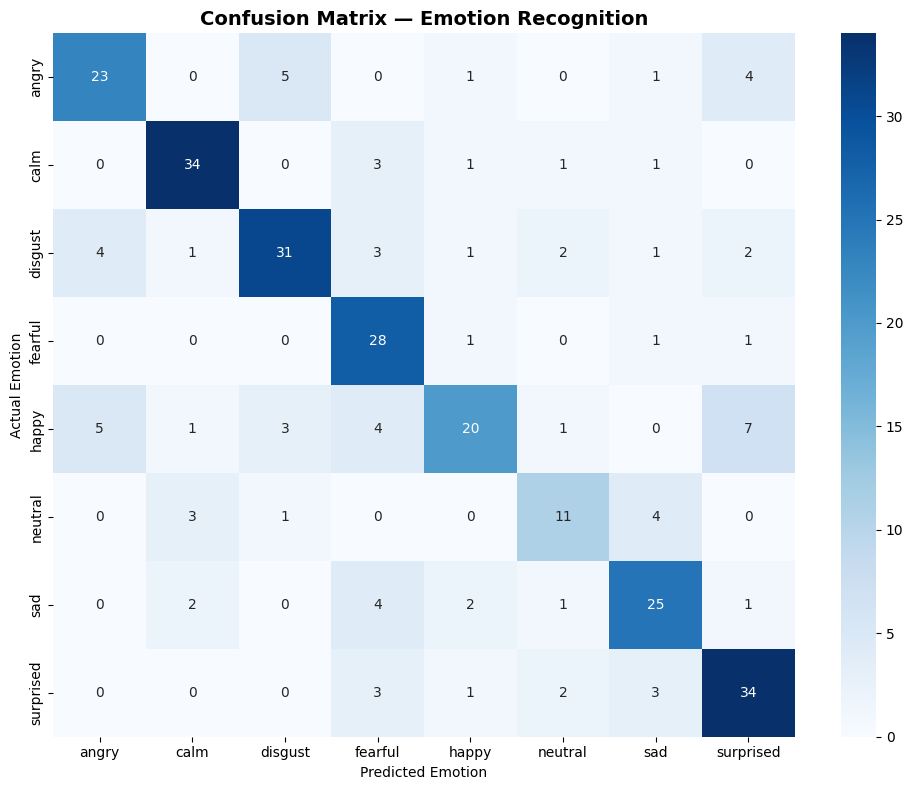

✅ Confusion Matrix Done!


In [7]:
# Detailed Report
print("="*50)
print("      📊 CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred, 
      target_names=le.classes_))

# --- Graph 1: Confusion Matrix ---
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix — Emotion Recognition', 
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted Emotion')
plt.ylabel('Actual Emotion')
plt.tight_layout()
plt.show()
print("✅ Confusion Matrix Done!")

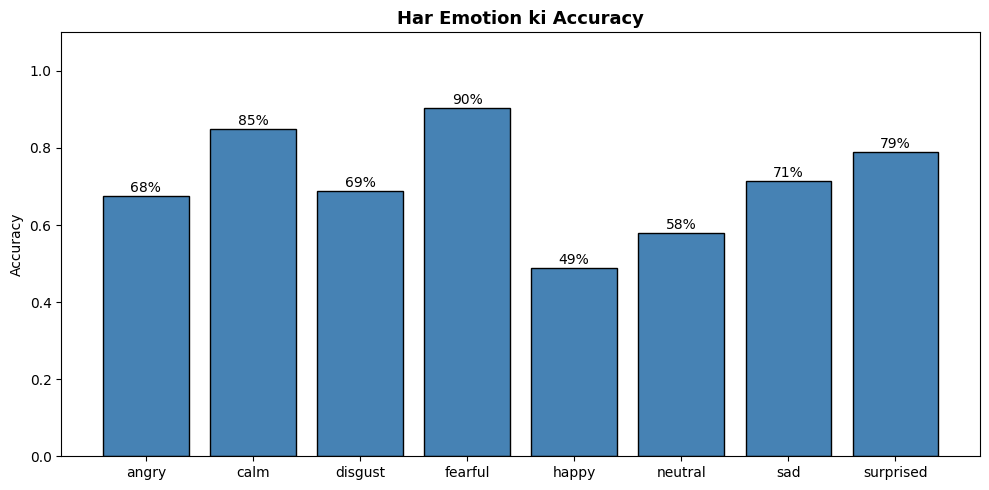

✅ Emotion Accuracy Graph Done!


In [8]:
# --- Graph 2: Emotion wise Accuracy ---
emotion_acc = {}
for i, emotion in enumerate(le.classes_):
    mask = y_test == i
    if mask.sum() > 0:
        emotion_acc[emotion] = accuracy_score(
            y_test[mask], y_pred[mask])

plt.figure(figsize=(10, 5))
bars = plt.bar(emotion_acc.keys(), 
               emotion_acc.values(),
               color='steelblue', edgecolor='black')

for bar, val in zip(bars, emotion_acc.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.0%}', ha='center', fontsize=10)

plt.title('Har Emotion ki Accuracy',
          fontsize=13, fontweight='bold')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()
print("✅ Emotion Accuracy Graph Done!")

## save last ##

In [9]:
# Final Summary
print("="*50)
print("   🏆 FINAL SUMMARY")
print("="*50)
print(f"\n  📌 Model    : MLP Neural Network")
print(f"  📌 Features : MFCC (40 coefficients)")
print(f"  📌 Dataset  : RAVDESS (1440 audio files)")
print(f"  📌 Actors   : 24 (12 Male, 12 Female)")
print(f"  📌 Emotions : {len(le.classes_)}")
print(f"\n  Emotions Detected:")
for emotion in le.classes_:
    print(f"    ✅ {emotion}")
print(f"\n  🎯 Final Accuracy : {acc*100:.2f}%")
print("\n" + "="*50)
print("  ✅ Task 2 Complete — Emotion Recognition!")
print("  👨‍💻 CodeAlpha ML Internship")
print("="*50)

   🏆 FINAL SUMMARY

  📌 Model    : MLP Neural Network
  📌 Features : MFCC (40 coefficients)
  📌 Dataset  : RAVDESS (1440 audio files)
  📌 Actors   : 24 (12 Male, 12 Female)
  📌 Emotions : 8

  Emotions Detected:
    ✅ angry
    ✅ calm
    ✅ disgust
    ✅ fearful
    ✅ happy
    ✅ neutral
    ✅ sad
    ✅ surprised

  🎯 Final Accuracy : 71.53%

  ✅ Task 2 Complete — Emotion Recognition!
  👨‍💻 CodeAlpha ML Internship
